# 1. Installing Dataset and Libraries

In [1]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/CSV\ COLAB/kaggle.json ~/.kaggle/

In [2]:
!kaggle competitions download -c shl-hiring-assessment

In [3]:
import zipfile

zip_ref = zipfile.ZipFile("/content/shl-hiring-assessment.zip","r")
zip_ref.extractall("/content")
zip_ref.close()

In [4]:
import pandas as pd

In [5]:
!pip install -q speechrecognition librosa pandas numpy language-tool-python torch transformers xgboost spacy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [6]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
!pip install -q git+https://github.com/openai/whisper.git pandas numpy language-tool-python xgboost
!apt-get update -q
!apt-get install -y -q openjdk-17-jdk ffmpeg
!update-alternatives --set java /usr/lib/jvm/java-17-openjdk-amd64/bin/java
!update-alternatives --set javac /usr/lib/jvm/java-17-openjdk-amd64/bin/javac

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [77.5 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,659 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,906 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois

In [8]:
import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-17-openjdk-amd64'

In [9]:
import pandas as pd
import numpy as np
import whisper
import language_tool_python
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Initialize tools
model = whisper.load_model("tiny")  # Fastest Whisper model
tool = language_tool_python.LanguageTool('en-US')

print("Setup complete. Using Whisper Tiny for transcription.")

100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 89.9MiB/s]
INFO:language_tool_python.download_lt:Unzipping /tmp/tmp5h9dy9nv.zip to /root/.cache/language_tool_python.
INFO:language_tool_python.download_lt:Downloaded https://internal1.languagetool.org/snapshots/LanguageTool-latest-snapshot.zip to /root/.cache/language_tool_python.


Setup complete. Using Whisper Tiny for transcription.


#  2. Data Loading and Exploration

In [11]:
path = "/content/Dataset/"
train = pd.read_csv(path+'train.csv')
test = pd.read_csv(path+'test.csv')
sample_submission = pd.read_csv(path+'sample_submission.csv')

In [12]:
# Display basic info
print("Training Data Shape:", train.shape)
print("Test Data Shape:", test.shape)
print("\nTraining Data Sample:")
print(train.head())

Training Data Shape: (444, 2)
Test Data Shape: (204, 1)

Training Data Sample:
         filename  label
0   audio_710.wav    1.0
1  audio_1265.wav    1.0
2  audio_1114.wav    1.5
3   audio_946.wav    1.5
4  audio_1127.wav    2.0


In [13]:
# # Plot score distribution
# plt.hist(train['score'], bins=20, edgecolor='black')
# plt.title('Distribution of Grammar Scores')
# plt.xlabel('Score (0–5)')
# plt.ylabel('Count')
# plt.show()

# 3. Speech-to-Text Transcription
### Converting WAV audio files to text using Wav2Vec2 for accurate transcription.

In [14]:
def transcribe_audio(file_path):
    """
    Transcribe a WAV audio file using Whisper Tiny.

    Args:
        file_path (str): Path to WAV file.

    Returns:
        str: Transcribed text or empty string if fails.
    """
    try:
        result = model.transcribe(file_path, fp16=False)  # CPU-compatible
        return result["text"].lower()
    except Exception as e:
        print(f"Error transcribing {file_path}: {e}")
        return ""

In [15]:
if os.path.exists('train_with_transcriptions.csv'):
    print("Loading existing training transcriptions...")
    train = pd.read_csv('train_with_transcriptions.csv')
    train['transcription'] = train['transcription'].fillna('')
else:
    print("Transcribing training audio...")
    train['transcription'] = train['filename'].apply(lambda x: transcribe_audio(f'/content/Dataset/audios/train/{x}'))
    train.to_csv('train_with_transcriptions.csv', index=False)

print("Transcribing test audio...")
test['transcription'] = test['filename'].apply(lambda x: transcribe_audio(f'/content/Dataset/audios/test/{x}'))
test.to_csv('test_with_transcriptions.csv', index=False)

# Fallback: If test transcription fails, use empty strings
test['transcription'] = test['transcription'].fillna('')

Transcribing training audio...
Transcribing test audio...


In [22]:
# sample transcriptions
print("\nSample Transcriptions:")
print(train[['filename', 'transcription']].head())


Sample Transcriptions:
         filename                                      transcription
0   audio_710.wav             (*s heed ms bonito pay hine� navanteks
1  audio_1265.wav   my favorite hobbies, cultivation of plants su...
2  audio_1114.wav   my goal is to become an electrical employee a...
3   audio_946.wav   the playground looks like very clear and neat...
4  audio_1127.wav   my goal is to bring my parents to live with m...


In [23]:
train[['transcription']].head()

,transcription
0,(*s heed ms bonito pay hine� navanteks
1,"my favorite hobbies, cultivation of plants su..."
2,my goal is to become an electrical employee a...
3,the playground looks like very clear and neat...
4,my goal is to bring my parents to live with m...


In [24]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from scipy.stats import pearsonr  # For Pearson correlation
import warnings
warnings.filterwarnings('ignore')

# 4. Feature Extraction
### Extract grammar features using LanguageTool

In [25]:
sample_submission = pd.read_csv('/content/Dataset/sample_submission.csv')

In [26]:
def get_grammar_features(text):
    """
    Extract grammar features using LanguageTool.

    Args:
        text (str): Transcribed text.

    Returns:
        dict: Grammar features (error count, error rate).
    """
    if not text or pd.isna(text):
        return {'error_count': 0, 'error_rate': 0}
    matches = tool.check(text)
    error_count = len(matches)
    sentence_count = len(text.split('.')) or 1
    error_rate = error_count / sentence_count
    return {'error_count': error_count, 'error_rate': error_rate}

In [27]:
def get_text_features(text):
    """
    Extract text-based features to improve model performance.

    Args:
        text (str): Transcribed text.

    Returns:
        dict: Text features (word count, unique words, etc.).
    """
    if not text or pd.isna(text):
        return {
            'num_words': 0,
            'num_unique_words': 0,
            'avg_word_length': 0,
            'num_sentences': 0,
            'avg_sentence_length': 0
        }
    words = text.split()
    num_words = len(words)
    num_unique_words = len(set(words))
    avg_word_length = sum(len(word) for word in words) / num_words if num_words > 0 else 0
    sentences = text.split('.')
    num_sentences = len(sentences) if sentences else 1
    avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0
    return {
        'num_words': num_words,
        'num_unique_words': num_unique_words,
        'avg_word_length': avg_word_length,
        'num_sentences': num_sentences,
        'avg_sentence_length': avg_sentence_length
    }

In [28]:
# Computing features
print("Extracting grammar features...")
train_grammar_features = train['transcription'].apply(get_grammar_features).apply(pd.Series)
test_grammar_features = test['transcription'].apply(get_grammar_features).apply(pd.Series)

print("Extracting text features...")
train_text_features = train['transcription'].apply(get_text_features).apply(pd.Series)
test_text_features = test['transcription'].apply(get_text_features).apply(pd.Series)

Extracting grammar features...
Extracting text features...


In [29]:
# Combining features
train_features = pd.concat([train_grammar_features, train_text_features], axis=1)
test_features = pd.concat([test_grammar_features, test_text_features], axis=1)

In [30]:
# Saving features
train_features.to_csv('train_features.csv', index=False)
test_features.to_csv('test_features.csv', index=False)

In [31]:
print("\nTrain Features Sample:")
print(train_features.head())
print("\nFeature Columns:", train_features.columns.tolist())


Train Features Sample:
   error_count  error_rate  num_words  num_unique_words  avg_word_length  \
0          2.0    2.000000        7.0               7.0         4.571429   
1          4.0    1.333333       31.0              26.0         5.161290   
2          5.0    1.666667       49.0              29.0         4.775510   
3          4.0    1.000000       43.0              38.0         4.255814   
4         15.0    1.363636      118.0              75.0         4.067797   

   num_sentences  avg_sentence_length  
0            1.0             7.000000  
1            3.0            10.333333  
2            3.0            16.333333  
3            4.0            10.750000  
4           11.0            10.727273  

Feature Columns: ['error_count', 'error_rate', 'num_words', 'num_unique_words', 'avg_word_length', 'num_sentences', 'avg_sentence_length']


# 3. Model Training and Evaluation

### Train XGBoost regressor and compute required metrics.

In [51]:
from xgboost import XGBRegressor

In [52]:
# Preparing data
score_column = 'label'
if score_column not in train.columns:
    raise ValueError(f"Expected column '{score_column}' not found in train DataFrame.")

In [53]:
# Preparing data (redefine to ensure correctness)
X = train_features
y = train[score_column]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
print("Training XGBoost regressor...")
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

Training XGBoost regressor...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [55]:
# Evaluation on training set (split)
y_train_pred = xgb_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
print(f"Training MSE (Split): {train_mse:.4f}")
print(f"Training RMSE (Split): {train_rmse:.4f}")

Training MSE (Split): 0.0156
Training RMSE (Split): 0.1248


In [56]:
# Evaluation on validation set
y_val_pred = xgb_model.predict(X_val)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_pearson, _ = pearsonr(y_val, y_val_pred)
print(f"Validation MSE: {val_mse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation Pearson Correlation: {val_pearson:.4f}")

Validation MSE: 1.4140
Validation RMSE: 1.1891
Validation Pearson Correlation: 0.2465


In [57]:
# Evaluation on full training data
y_full_pred = xgb_model.predict(X)
full_train_mse = mean_squared_error(y, y_full_pred)
full_train_rmse = np.sqrt(full_train_mse)
print(f"Full Training MSE: {full_train_mse:.4f}")
print(f"Full Training RMSE: {full_train_rmse:.4f}")

Full Training MSE: 0.2959
Full Training RMSE: 0.5439


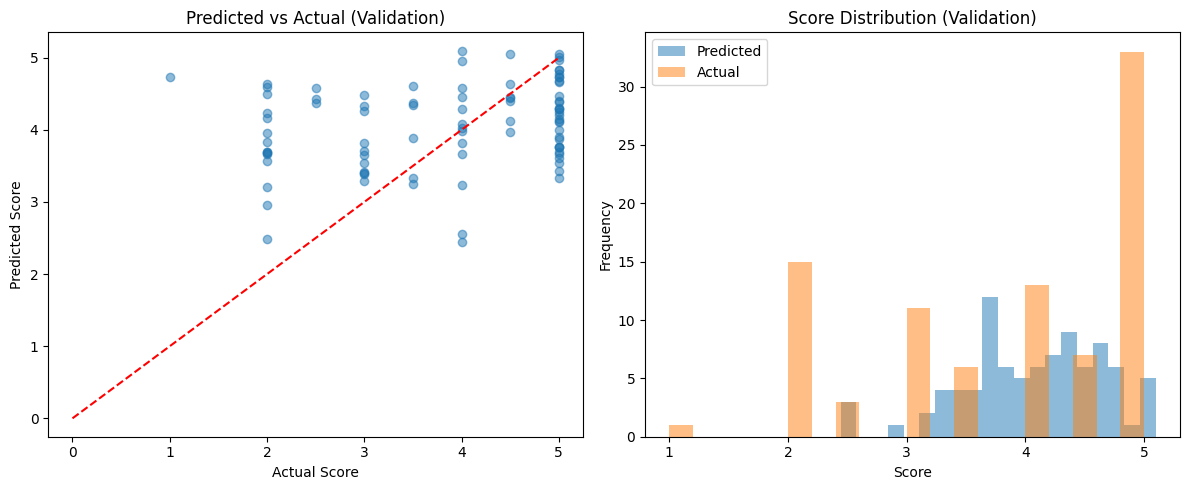

In [58]:
# Visualizations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_val, y_val_pred, alpha=0.5)
plt.plot([0, 5], [0, 5], 'r--')
plt.title('Predicted vs Actual (Validation)')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.xticks([0, 1, 2, 3, 4, 5])
plt.yticks([0, 1, 2, 3, 4, 5])

plt.subplot(1, 2, 2)
plt.hist(y_val_pred, bins=20, alpha=0.5, label='Predicted')
plt.hist(y_val, bins=20, alpha=0.5, label='Actual')
plt.title('Score Distribution (Validation)')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

#4. Test Prediction

In [62]:
print("Generating test predictions...")
test_predictions = xgb_model.predict(test_features)
test_predictions = np.clip(test_predictions, 0, 5)

Generating test predictions...


In [63]:
submission = pd.DataFrame({'filename': test['filename'], 'label': test_predictions})
submission.to_csv('submission.csv', index=False)

In [64]:
print("\nSubmission File Sample:")
print(submission.head())


Submission File Sample:
         filename     label
0   audio_804.wav  2.030269
1  audio_1028.wav  3.854424
2   audio_865.wav  3.111964
3   audio_774.wav  3.550459
4  audio_1138.wav  3.390182
